# 04 — Temporal analysis

Checks timestamp coverage, activity cadence, and suspicious-label rates over time.

In [1]:
# Setup
from pathlib import Path
import logging, random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
random.seed(42); np.random.seed(42)
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
paths = [p for root in (Path('/kaggle/input'), Path('data/original')) if root.exists() for p in root.rglob('ml_features.csv')]
if not paths: raise FileNotFoundError('Upload the source bundle to Kaggle Input or data/original.')
df = pd.read_csv(paths[0], parse_dates={'timestamp': ['Date', 'Time']})


/tmp/ipykernel_58/4135918502.py:11: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(paths[0], parse_dates={'timestamp': ['Date', 'Time']})


Timestamp range: 2022-10-07 10:35:19 to 2022-11-06 21:04:35
Distinct calendar dates: 10


,transactions,suspicious_rate
timestamp,,
2022-10-07,20892,0.001292
2022-10-08,29023,0.000999
2022-10-09,28880,0.001108
2022-10-10,21205,0.001226
2022-11-01,36,1.000000
2022-11-02,46,1.000000
2022-11-03,66,1.000000
2022-11-04,40,1.000000
2022-11-05,26,1.000000


,transactions,suspicious_rate
hour_of_day,,
0,1140,0.003509
1,1106,0.008137
2,1116,0.005376
3,1152,0.011285
4,1112,0.009892
5,1115,0.008969
6,1079,0.013902
7,1299,0.007698
8,4739,0.002532


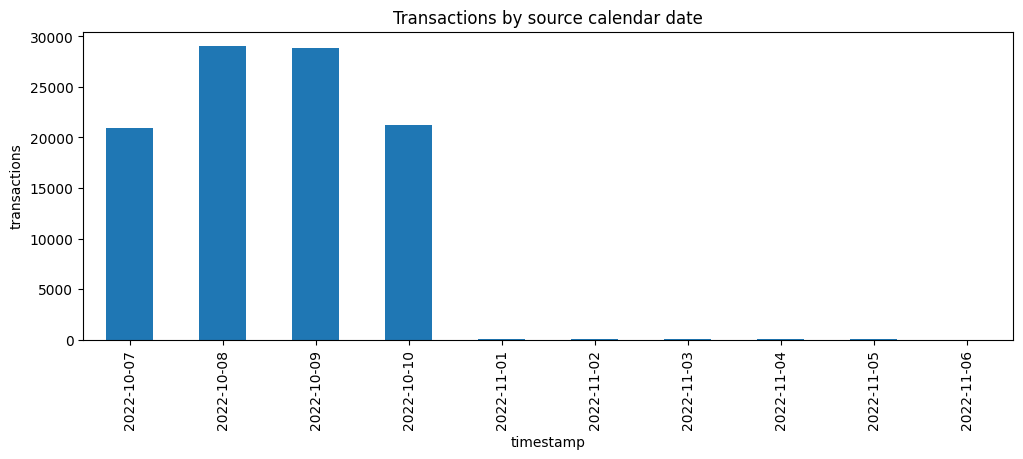

In [2]:
print('Timestamp range:', df['timestamp'].min(), 'to', df['timestamp'].max())
print('Distinct calendar dates:', df['timestamp'].dt.date.nunique())
daily = df.groupby(df['timestamp'].dt.date).agg(transactions=('timestamp', 'size'), suspicious_rate=('is_suspicious_tx', 'mean'))
display(daily)
hourly = df.groupby('hour_of_day').agg(transactions=('hour_of_day', 'size'), suspicious_rate=('is_suspicious_tx', 'mean'))
display(hourly)
daily['transactions'].plot(kind='bar', figsize=(12, 4), title='Transactions by source calendar date')
plt.ylabel('transactions'); plt.show()


## Conclusion
Confirm the source’s timestamp continuity before generating the planned one-year history. Recompute rolling features after canonical timestamps are produced.